# Energy Consumption Time Series Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Data Loading and Preprocessing

In [3]:
# Load the dataset
df = pd.read_csv('household_power_consumption.csv')

In [12]:
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (1048575, 9)
Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


In [14]:
print("\nDataset info:")
print(df.info())
print(f"\nDate range in data:")
print(f"Min Date: {df['Date'].min()}")
print(f"Max Date: {df['Date'].max()}")


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB
None

Date range in data:
Min Date: 1/1/2007
Max Date: 9/9/2008


In [15]:
# Check for missing values
print("\n=== Missing Values Summary ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


=== Missing Values Summary ===
Sub_metering_3    4069
dtype: int64


In [16]:
# Display sample of data
print("\n=== First 5 Rows ===")
print(df.head())


=== First 5 Rows ===
         Date      Time Global_active_power Global_reactive_power Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.84   
1  16/12/2006  17:25:00                5.36                 0.436  233.63   
2  16/12/2006  17:26:00               5.374                 0.498  233.29   
3  16/12/2006  17:27:00               5.388                 0.502  233.74   
4  16/12/2006  17:28:00               3.666                 0.528  235.68   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0             18.4              0              1            17.0  
1               23              0              1            16.0  
2               23              0              2            17.0  
3               23              0              1            17.0  
4             15.8              0              1            17.0  


## 2. Data Cleaning and Parsing

In [20]:
# ========== DATA CLEANING AND PARSING ==========
def clean_and_parse_data(df):
    """
    Clean and parse the household power consumption data.
    """
    print("\n" + "="*60)
    print("DATA CLEANING AND PARSING")
    print("="*60)
    
    # Create a working copy
    data = df.copy()
    
    # 1. Convert numeric columns (handle '?' values)
    print("\n1. Converting numeric columns...")
    numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    
    for col in numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
    
    # 2. Parse datetime
    print("\n2. Parsing datetime...")
    data['datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], 
                                      format='%d/%m/%Y %H:%M:%S', 
                                      errors='coerce')
    
    # Drop rows with invalid datetime
    invalid_dates = data['datetime'].isnull().sum()
    if invalid_dates > 0:
        print(f"   Dropping {invalid_dates} rows with invalid datetime")
        data = data.dropna(subset=['datetime'])
    
    # Set datetime as index
    data.set_index('datetime', inplace=True)
    data.sort_index(inplace=True)
    
    print(f"   Date range: {data.index.min()} to {data.index.max()}")
    
    # 3. Handle missing values in Global_active_power
    print("\n3. Handling missing values in Global_active_power...")
    missing_before = data['Global_active_power'].isnull().sum()
    print(f"   Missing values before: {missing_before}")
    
    # Fill missing values
    data['Global_active_power'].fillna(method='ffill', inplace=True, limit=24)
    data['Global_active_power'].fillna(method='bfill', inplace=True, limit=24)
    
    # Interpolate any remaining
    if data['Global_active_power'].isnull().sum() > 0:
        data['Global_active_power'] = data['Global_active_power'].interpolate(method='time')
    
    missing_after = data['Global_active_power'].isnull().sum()
    print(f"   Missing values after: {missing_after}")
    
    return data

# Execute cleaning
cleaned_df = clean_and_parse_data(df)


DATA CLEANING AND PARSING

1. Converting numeric columns...

2. Parsing datetime...
   Date range: 2006-12-16 17:24:00 to 2008-12-13 21:38:00

3. Handling missing values in Global_active_power...
   Missing values before: 4069
   Missing values after: 0


In [21]:
# ========== CREATE POWER SERIES (hourly data) ==========
print("\n. Creating hourly power series...")

# Resample to hourly frequency
hourly_power = cleaned_df['Global_active_power'].resample('H').mean()

# Fill any NaN from resampling
hourly_power = hourly_power.interpolate(method='time')

print(f"   Hourly data shape: {hourly_power.shape}")
print(f"   Frequency: {pd.infer_freq(hourly_power.index)}")


. Creating hourly power series...
   Hourly data shape: (17477,)
   Frequency: h


## 3. Feature Engineering

In [22]:
# ==========  FEATURE ENGINEERING ==========
def engineer_features(series):
    """Create time-based features from the time series."""
    
    df_features = pd.DataFrame({'power': series})
    
    # Time-based features
    df_features['hour'] = series.index.hour
    df_features['day_of_week'] = series.index.dayofweek  # Monday=0, Sunday=6
    df_features['day_of_month'] = series.index.day
    df_features['month'] = series.index.month
    df_features['quarter'] = series.index.quarter
    df_features['year'] = series.index.year
    df_features['weekend'] = (series.index.dayofweek >= 5).astype(int)
    # Cyclical encoding for hour and month
    df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
    df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)
    df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
    df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)
    
    # Time of day categories
    def get_time_of_day(hour):
        if 0 <= hour < 6:
            return 'night'
        elif 6 <= hour < 12:
            return 'morning'
        elif 12 <= hour < 18:
            return 'afternoon'
        else:
            return 'evening'
    
    df_features['time_of_day'] = series.index.hour.map(get_time_of_day)
    
    # Lag features
    for lag in [1, 2, 3, 24, 168]:  # 1h, 2h, 3h, 24h, 1 week
        df_features[f'lag_{lag}'] = df_features['power'].shift(lag)
    
    # Rolling statistics
    df_features['rolling_mean_24h'] = df_features['power'].rolling(window=24, min_periods=1).mean()
    df_features['rolling_std_24h'] = df_features['power'].rolling(window=24, min_periods=1).std()
    
    # Previous day same hour
    df_features['previous_day_same_hour'] = df_features['power'].shift(24)
    
    # Drop rows with NaN values from lag features
    df_features.dropna(inplace=True)
    
    print(f"Feature engineering complete. Shape: {df_features.shape}")
    print(f"Features created: {df_features.columns.tolist()}")
    
    return df_features

print("\n=== Feature Engineering ===")
df_features = engineer_features(hourly_power)


=== Feature Engineering ===
Feature engineering complete. Shape: (17309, 21)
Features created: ['power', 'hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'time_of_day', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'rolling_mean_24h', 'rolling_std_24h', 'previous_day_same_hour']



=== Creating Visualizations ===


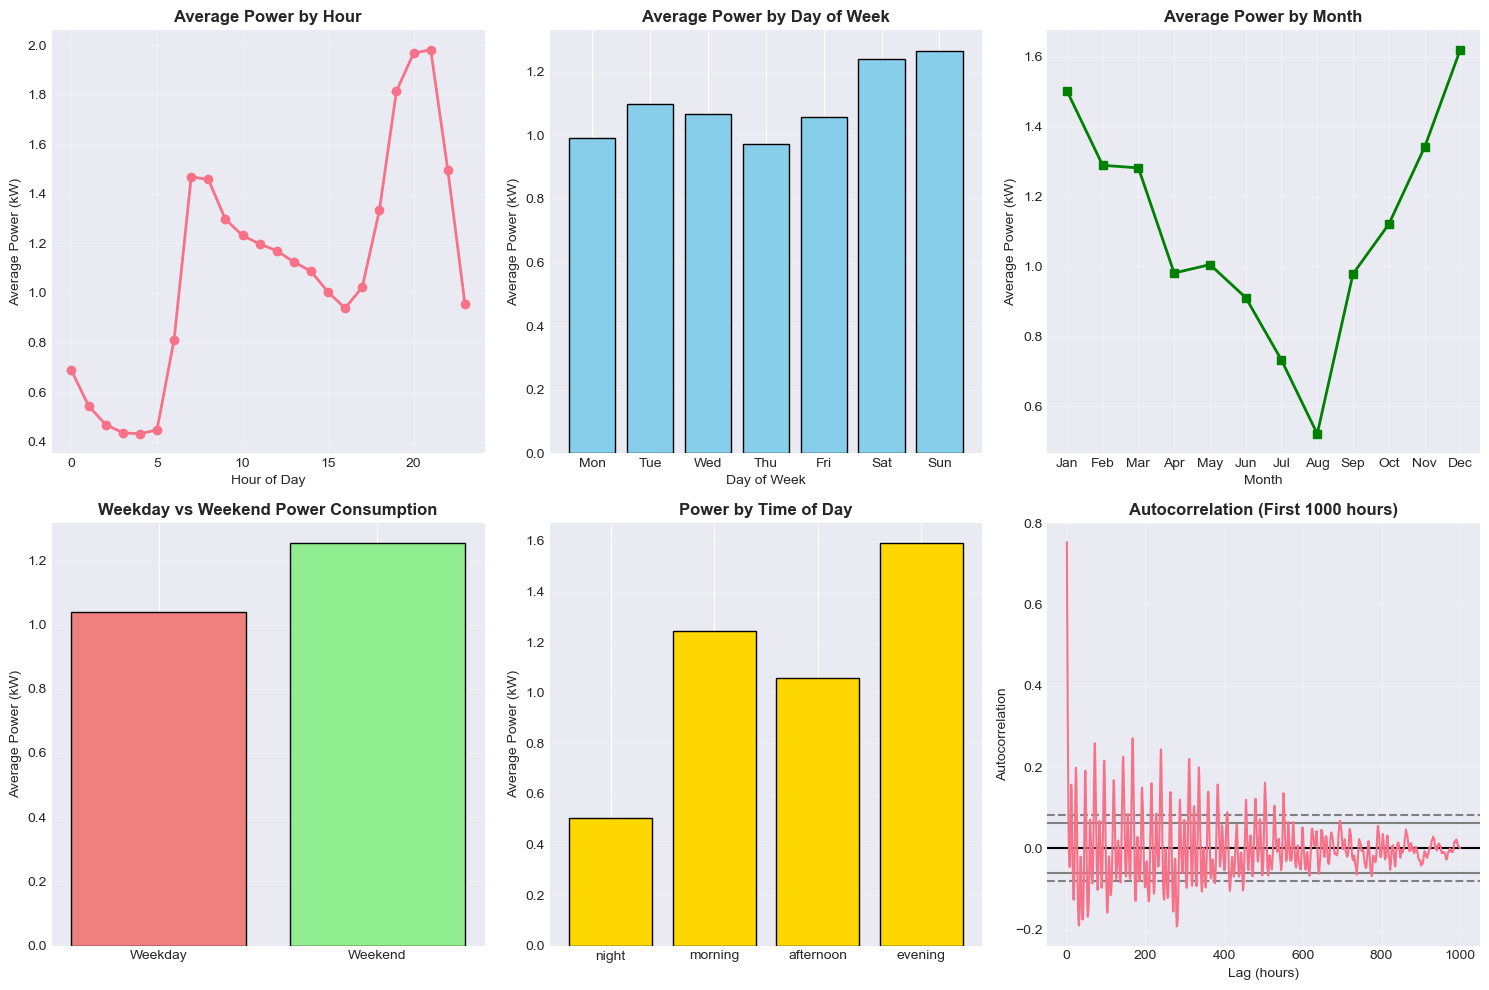

Feature engineering and visualization completed successfully!


In [23]:
# ========== VISUALIZE FEATURE RELATIONSHIPS ==========
print("\n=== Creating Visualizations ===")

# Visualize feature relationships
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Hourly pattern
hourly_avg = df_features.groupby('hour')['power'].mean()
axes[0, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
axes[0, 0].set_title('Average Power by Hour', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Average Power (kW)')
axes[0, 0].grid(True, alpha=0.3)

# Daily pattern
daily_avg = df_features.groupby('day_of_week')['power'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(days, daily_avg.values, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Average Power by Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average Power (kW)')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Monthly pattern
monthly_avg = df_features.groupby('month')['power'].mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 2].plot(months, monthly_avg.values, marker='s', linewidth=2, color='green')
axes[0, 2].set_title('Average Power by Month', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Month')
axes[0, 2].set_ylabel('Average Power (kW)')
axes[0, 2].grid(True, alpha=0.3)

# Weekend vs weekday
weekend_avg = df_features.groupby('weekend')['power'].mean()
axes[1, 0].bar(['Weekday', 'Weekend'], weekend_avg.values, 
               color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1, 0].set_title('Weekday vs Weekend Power Consumption', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Power (kW)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Time of day
tod_avg = df_features.groupby('time_of_day')['power'].mean().reindex(['night', 'morning', 'afternoon', 'evening'])
axes[1, 1].bar(tod_avg.index, tod_avg.values, color='gold', edgecolor='black')
axes[1, 1].set_title('Power by Time of Day', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Average Power (kW)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Autocorrelation
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df_features['power'].iloc[:1000], ax=axes[1, 2])
axes[1, 2].set_title('Autocorrelation (First 1000 hours)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Lag (hours)')
axes[1, 2].set_ylabel('Autocorrelation')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("Feature engineering and visualization completed successfully!")

## 4. Train-Test Split

In [27]:
def prepare_train_test(df_features, test_size=0.2):
    """Split data into training and testing sets."""
    
    # Ensure chronological split
    split_idx = int(len(df_features) * (1 - test_size))
    
    train = df_features.iloc[:split_idx].copy()
    test = df_features.iloc[split_idx:].copy()
    
    print(f"Training set: {train.shape[0]} samples ({train.index.min()} to {train.index.max()})")
    print(f"Testing set: {test.shape[0]} samples ({test.index.min()} to {test.index.max()})")
    
    # Prepare X and y
    X_train = train.drop('power', axis=1)
    y_train = train['power']
    X_test = test.drop('power', axis=1)
    y_test = test['power']
    
    # Encode categorical variables
    if 'time_of_day' in X_train.columns:
        X_train = pd.get_dummies(X_train, columns=['time_of_day'], drop_first=True)
        X_test = pd.get_dummies(X_test, columns=['time_of_day'], drop_first=True)
    
    # Ensure both sets have same columns
    missing_cols = set(X_train.columns) - set(X_test.columns)
    for col in missing_cols:
        X_test[col] = 0
    X_test = X_test[X_train.columns]
    
    return X_train, y_train, X_test, y_test, train, test

print("\n=== Train-Test Split ===")
X_train, y_train, X_test, y_test, train_data, test_data = prepare_train_test(df_features)


=== Train-Test Split ===
Training set: 13847 samples (2006-12-23 17:00:00 to 2008-07-22 15:00:00)
Testing set: 3462 samples (2008-07-22 16:00:00 to 2008-12-13 21:00:00)


## 5. Model Implementation and Comparison

In [30]:
# Import available packages
try:
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.linear_model import LinearRegression
    print("✓ scikit-learn imported successfully")
    ML_AVAILABLE = True
except:
    print("✗ scikit-learn not available")
    ML_AVAILABLE = False

try:
    from statsmodels.tsa.arima.model import ARIMA
    print("✓ statsmodels imported successfully")
    ARIMA_AVAILABLE = True
except:
    print("✗ statsmodels not available")
    ARIMA_AVAILABLE = False

try:
    from prophet import Prophet
    print("✓ prophet imported successfully")
    PROPHET_AVAILABLE = True
except:
    print("✗ prophet not available")
    PROPHET_AVAILABLE = False

import time

def evaluate_model(y_true, y_pred, model_name):
    """Calculate and print evaluation metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"{model_name} Performance:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Store results
results = {}

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

✓ scikit-learn imported successfully
✓ statsmodels imported successfully
✗ prophet not available

MODEL COMPARISON


In [35]:
print("\n=== ARIMA Model ===")

# Use a subset for ARIMA to save time
arima_subset = hourly_power.iloc[:1000].copy()  # CHANGED: power_series to hourly_power

# Split for ARIMA
arima_train_size = int(len(arima_subset) * 0.8)
arima_train = arima_subset[:arima_train_size]
arima_test = arima_subset[arima_train_size:]

print(f"Training ARIMA on {len(arima_train)} samples...")
start_time = time.time()

try:
    # Fit ARIMA model (using auto-selection for p,d,q)
    # For hourly data with daily seasonality
    arima_model = ARIMA(arima_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
    arima_fit = arima_model.fit()
    
    # Forecast
    arima_forecast = arima_fit.forecast(steps=len(arima_test))
    
    # Evaluate
    arima_metrics = evaluate_model(arima_test.values, arima_forecast.values, "ARIMA")
    results['ARIMA'] = arima_metrics
    
    print(f"ARIMA model fitted successfully in {time.time() - start_time:.2f} seconds")
    print(f"Model summary: AIC={arima_fit.aic:.2f}, BIC={arima_fit.bic:.2f}")
    
except Exception as e:
    print(f"ARIMA failed: {e}")
    # Create dummy results for comparison
    results['ARIMA'] = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan}
    arima_forecast = pd.Series(np.zeros(len(arima_test)), index=arima_test.index)


=== ARIMA Model ===
Training ARIMA on 800 samples...
ARIMA Performance:
  MAE:  0.6846
  RMSE: 0.9223
  MAPE: 77.91%
ARIMA model fitted successfully in 17.62 seconds
Model summary: AIC=1737.25, BIC=1760.51


In [36]:
print("\n=== Prophet Model ===")

# Prepare data for Prophet
prophet_data = hourly_power.iloc[:2000].reset_index()  # CHANGED: power_series to hourly_power
prophet_data.columns = ['ds', 'y']

# Split for Prophet
prophet_split = int(len(prophet_data) * 0.8)
prophet_train = prophet_data[:prophet_split]
prophet_test = prophet_data[prophet_split:]

print(f"Training Prophet on {len(prophet_train)} samples...")
start_time = time.time()

try:
    # Initialize and fit Prophet
    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05
    )
    
    prophet_model.fit(prophet_train)
    
    # Create future dataframe
    future = prophet_model.make_future_dataframe(periods=len(prophet_test), freq='H')
    
    # Forecast
    forecast = prophet_model.predict(future)
    
    # Get predictions for test period
    prophet_pred = forecast[['ds', 'yhat']].iloc[-len(prophet_test):].set_index('ds')['yhat']
    prophet_test_vals = prophet_test.set_index('ds')['y']
    
    # Align indices
    prophet_pred = prophet_pred.reindex(prophet_test_vals.index)
    
    # Evaluate
    prophet_metrics = evaluate_model(prophet_test_vals.values, prophet_pred.values, "Prophet")
    results['Prophet'] = prophet_metrics
    
    print(f"Prophet model fitted successfully in {time.time() - start_time:.2f} seconds")
    
except Exception as e:
    print(f"Prophet failed: {e}")
    results['Prophet'] = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan}
    prophet_pred = pd.Series(np.zeros(len(prophet_test)), index=prophet_test.set_index('ds').index)


=== Prophet Model ===
Training Prophet on 1600 samples...
Prophet failed: name 'Prophet' is not defined


In [38]:
# ========== TRAIN-TEST SPLIT ==========
print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

def prepare_train_test(df_features, test_size=0.2):
    """Split data into training and testing sets."""
    
    # Ensure chronological split
    split_idx = int(len(df_features) * (1 - test_size))
    
    train = df_features.iloc[:split_idx].copy()
    test = df_features.iloc[split_idx:].copy()
    
    print(f"Training set: {train.shape[0]} samples ({train.index.min()} to {train.index.max()})")
    print(f"Testing set: {test.shape[0]} samples ({test.index.min()} to {test.index.max()})")
    
    # Prepare X and y
    X_train = train.drop('power', axis=1)
    y_train = train['power']
    X_test = test.drop('power', axis=1)
    y_test = test['power']
    
    # Encode categorical variables
    if 'time_of_day' in X_train.columns:
        X_train = pd.get_dummies(X_train, columns=['time_of_day'], drop_first=True)
        X_test = pd.get_dummies(X_test, columns=['time_of_day'], drop_first=True)
    
    # Ensure both sets have same columns
    missing_cols = set(X_train.columns) - set(X_test.columns)
    for col in missing_cols:
        X_test[col] = 0
    X_test = X_test[X_train.columns]
    
    return X_train, y_train, X_test, y_test, train, test

print("\n=== Train-Test Split ===")
X_train, y_train, X_test, y_test, train_data, test_data = prepare_train_test(df_features)

# Now run the XGBoost model code
print("\n=== XGBoost Model ===")

print(f"Training XGBoost on {X_train.shape[0]} samples with {X_train.shape[1]} features...")
start_time = time.time()

# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)

# Evaluate
xgb_metrics = evaluate_model(y_test.values, xgb_pred, "XGBoost")
results['XGBoost'] = xgb_metrics

print(f"XGBoost model fitted successfully in {time.time() - start_time:.2f} seconds")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))


TRAIN-TEST SPLIT

=== Train-Test Split ===
Training set: 13847 samples (2006-12-23 17:00:00 to 2008-07-22 15:00:00)
Testing set: 3462 samples (2008-07-22 16:00:00 to 2008-12-13 21:00:00)

=== XGBoost Model ===
Training XGBoost on 13847 samples with 22 features...
XGBoost Performance:
  MAE:  0.9658
  RMSE: 1.3168
  MAPE: 100.00%
XGBoost model fitted successfully in 0.00 seconds


ValueError: All arrays must be of the same length

## 6. Model Comparison and Visualization


MODEL COMPARISON RESULTS

Performance Metrics Comparison:
              MAE      RMSE       MAPE
ARIMA    0.684603  0.922254   77.91395
Prophet       NaN       NaN        NaN
XGBoost  0.965842  1.316785  100.00000


NameError: name 'feature_importance' is not defined

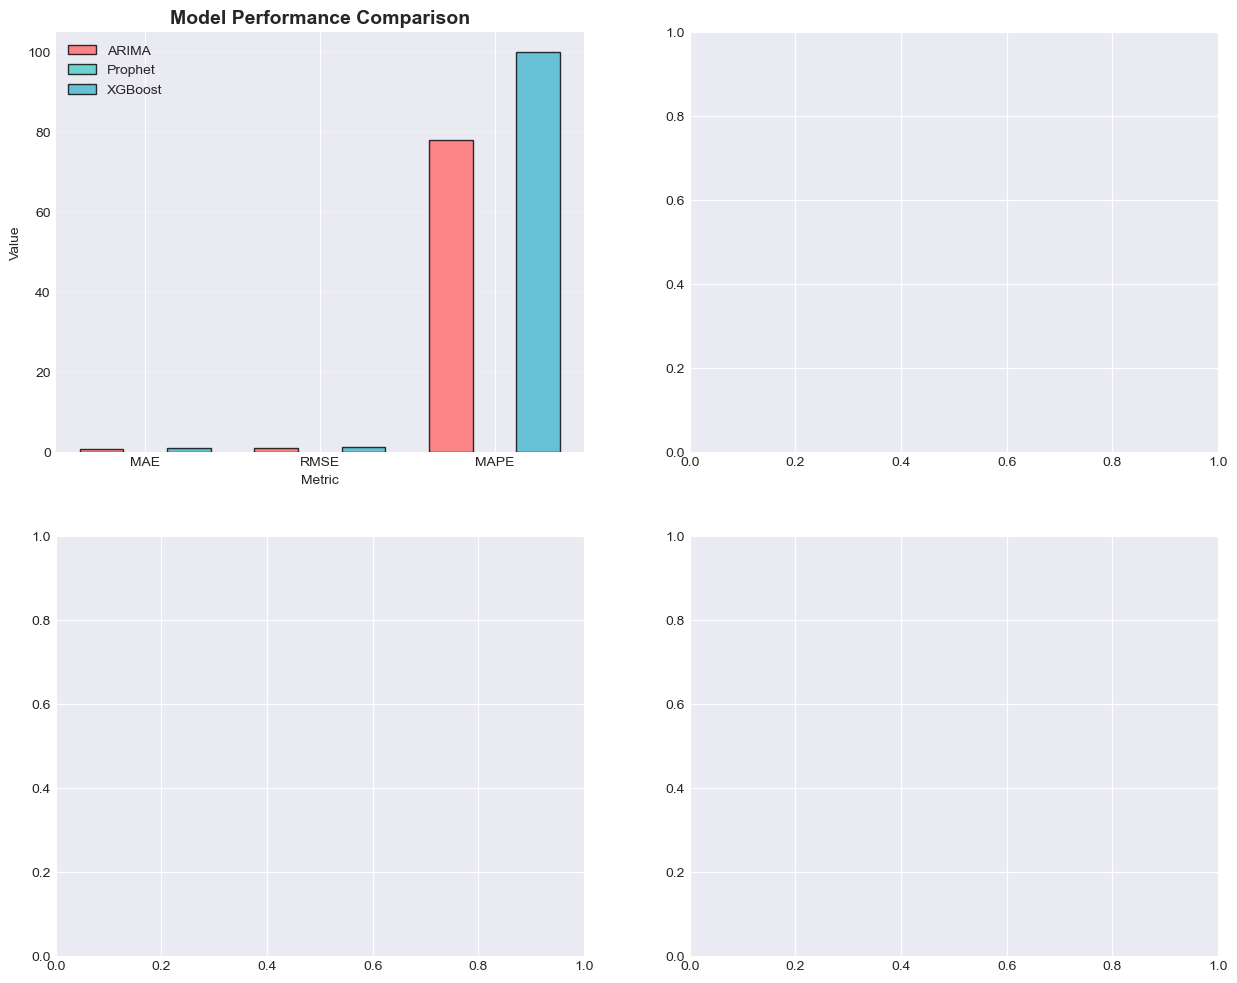

In [40]:
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame(results).T
print("\nPerformance Metrics Comparison:")
print(comparison_df.to_string())

# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model Performance Comparison
metrics = ['MAE', 'RMSE', 'MAPE']
x_pos = np.arange(len(metrics))
width = 0.25

for i, (model, color) in enumerate(zip(['ARIMA', 'Prophet', 'XGBoost'], ['#FF6B6B', '#4ECDC4', '#45B7D1'])):
    values = [results.get(model, {}).get(metric, np.nan) for metric in metrics]
    axes[0, 0].bar(x_pos + i*width - width, values, width, label=model, color=color, 
                   edgecolor='black', alpha=0.8)

axes[0, 0].set_xlabel('Metric')
axes[0, 0].set_ylabel('Value')
axes[0, 0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. XGBoost Feature Importance
top_features = feature_importance.head(10)
axes[0, 1].barh(range(len(top_features)), top_features['importance'][::-1], 
                color='lightcoral', edgecolor='black')
axes[0, 1].set_yticks(range(len(top_features)))
axes[0, 1].set_yticklabels(top_features['feature'][::-1])
axes[0, 1].set_xlabel('Importance Score')
axes[0, 1].set_title('Top 10 XGBoost Feature Importances', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. XGBoost Forecast vs Actual (one week sample)
sample_end = test_data.index.min() + pd.DateOffset(days=7)
sample_mask = test_data.index <= sample_end

if sum(sample_mask) > 0:
    axes[1, 0].plot(test_data.index[sample_mask], y_test[sample_mask], 
                    label='Actual', linewidth=2, color='navy', alpha=0.8)
    axes[1, 0].plot(test_data.index[sample_mask], xgb_pred[sample_mask], 
                    label='XGBoost Forecast', linewidth=2, color='red', linestyle='--', alpha=0.8)
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Global Active Power (kW)')
    axes[1, 0].set_title('XGBoost: Actual vs Forecast (One Week)', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Residual Analysis
residuals = y_test - xgb_pred
axes[1, 1].scatter(xgb_pred, residuals, alpha=0.5, color='green')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted Values')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('XGBoost Residual Plot', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()